In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [71]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuración para mostrar todas las columnas y filas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [72]:
data = pd.read_excel("data.xls")


In [73]:
# Read all sheets from the Excel file into a dictionary of DataFrames
file_path = "data.xls"
all_sheets = pd.read_excel(file_path, sheet_name=None)

# You can access each DataFrame using its sheet name, for example:
df_lotes = all_sheets['LotesVendidos']
df_cliente_zona = all_sheets['ClienteZona']
df_zona_ciudad = all_sheets['ZonaCiudad']
df_precios = all_sheets['ListaPrecios']

print(f"Sheets found: {list(all_sheets.keys())}")

Sheets found: ['LotesVendidos', 'ClienteZona', 'ZonaCiudad', 'ListaPrecios']


In [74]:
print("✓ Datos cargados exitosamente")
print(f"\n📊 Registros por tabla:")
print(f"  - LotesVendidos: {len(df_lotes):,} registros")
print(f"  - ClienteZona: {len(df_cliente_zona):,} registros")
print(f"  - ZonaCiudad: {len(df_zona_ciudad):,} registros")
print(f"  - ListaPrecios: {len(df_precios):,} registros")

✓ Datos cargados exitosamente

📊 Registros por tabla:
  - LotesVendidos: 26,194 registros
  - ClienteZona: 38 registros
  - ZonaCiudad: 7 registros
  - ListaPrecios: 10,100 registros


In [75]:
precios = df_precios.copy() # ListaPrecios
zonas = df_zona_ciudad.copy() # ZonaCiudad
cli_zona = df_cliente_zona.copy() # ClienteZona
lotes = df_lotes.copy() # LotesVendidos

# Convertir la fecha de venta a datetime (formato yyyymmdd)
lotes['Fechaa'] = pd.to_datetime(
lotes['Fecha'].astype(str),
format='%Y%m%d',
errors='coerce'
)
# Crear columnas de Año y Mes, ayuda aunir con ListaPrecios
lotes['Año'] = lotes['Fechaa'].dt.year
lotes['Mes'] = lotes['Fechaa'].dt.month

In [76]:
######### PREPARACION DE JOIN ENTRE: LOTES VENDIDOS + LISTA DE PRECIOS #########
# En LotesVendidos el artículo se llama 'Id_Artículo'
# En ListaPrecios el artículo se llama 'Id_Artículo'

ventas = lotes.merge(
    precios,
    left_on=['Id_Artículo', 'Año', 'Mes'],
    right_on=['Id_Artículo', 'Año', 'Mes'],
    how='left'
)
ventas['Cantidad'] = 1

# Calcular importe = Precio * Cantidad
ventas['Importe'] = ventas['Precio'] * ventas['Cantidad']

######### PREPARACION DE JOIN ENTRE: CLIENTE -> ZONA -> CIUDAD #########
# ClienteZona (añadir columna Zona)
ventas = ventas.merge(cli_zona, on='Id_Cliente', how='left')

# ZonaCiudad (añadir claves de ciudad)
ventas = ventas.merge(zonas, on='Zona', how='left')

# Renombrar la columna 'Unnamed: 2' si existe
if 'Unnamed: 2' in ventas.columns:
  ventas = ventas.rename(columns={'Unnamed: 2': 'NombreCiudad'})

In [77]:
total_registros = len(ventas)
total_unidades = ventas['Cantidad'].sum()
total_ventas = ventas['Importe'].sum()
precio_promedio = ventas['Precio'].mean()
importe_promedio = ventas['Importe'].mean()


print(f"Total de registros de venta: {total_registros}")
print(f"Total de unidades vendidas: {total_unidades:,.0f}")
print(f"Total de ventas (importe): ${total_ventas:,.2f}")
print("\n===== PROMEDIOS =====")
print(f"Precio promedio de los artículos: ${precio_promedio:,.2f}")
print(f"Importe promedio por venta (registro): ${importe_promedio:,.2f}")
# ===== TOTALES

Total de registros de venta: 26194
Total de unidades vendidas: 26,194
Total de ventas (importe): $25,056,110.00

===== PROMEDIOS =====
Precio promedio de los artículos: $956.56
Importe promedio por venta (registro): $956.56


In [78]:
ventas_por_año = ventas.groupby('Año')['Importe'].sum().sort_index()
print("\n===== VENTAS POR AÑO =====")
print(ventas_por_año)
año_mas_ventas = ventas_por_año.idxmax()
monto_mas_ventas = ventas_por_año.max()
año_menos_ventas = ventas_por_año.idxmin()
monto_menos_ventas = ventas_por_año.min()
print(f"\nAño con MÁS ventas: {año_mas_ventas} -> ${monto_mas_ventas:,.2f}")
print(f"Año con MENOS ventas: {año_menos_ventas} -> ${monto_menos_ventas:,.2f}")


===== VENTAS POR AÑO =====
Año
1998     674200
1999    3129190
2000    1915430
2001    2065745
2002    2607785
2003    2400970
2004    5037815
2005    3016425
2006    3564225
2007     644325
Name: Importe, dtype: int64

Año con MÁS ventas: 2004 -> $5,037,815.00
Año con MENOS ventas: 2007 -> $644,325.00


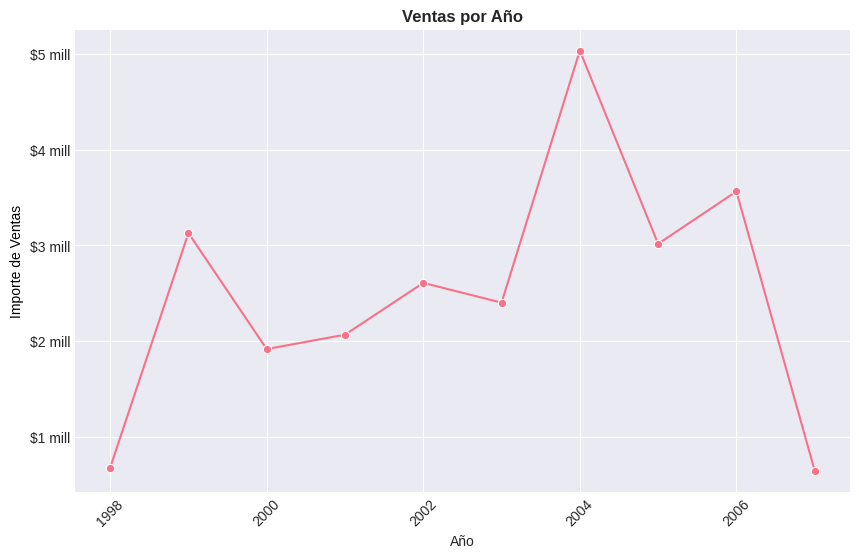

In [79]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))
sns.lineplot(data=ventas_por_año, marker='o')
plt.title('Ventas por Año', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Importe de Ventas', color='black')
plt.xticks(rotation=45)
plt.grid(True)

# Custom y-axis ticks and labels
y_ticks = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]
y_labels = ['$1 mill', '$2 mill', '$3 mill', '$4 mill', '$5 mill']
plt.yticks(y_ticks, y_labels)

plt.show()

In [80]:
ventas_por_articulo = ventas.groupby('Id_Artículo')['Cantidad'].sum().sort_values(ascending=False)

print("\n===== VENTAS POR ARTÍCULO (CANTIDAD) =====")
print(ventas_por_articulo.head(10))
art_mas = ventas_por_articulo.idxmax()
cant_mas = ventas_por_articulo.max()
art_menos = ventas_por_articulo.idxmin()
cant_menos = ventas_por_articulo.min()
print(f"\nArtículo MÁS vendido: {art_mas} -> {cant_mas} unidades")
print(f"Artículo MENOS vendido: {art_menos} -> {cant_menos} unidades")

# Calculate total revenue for the best-selling article
importe_art_mas_vendido = ventas[ventas['Id_Artículo'] == art_mas]['Importe'].sum()
print(f"\nDinero en ventas registrado por el artículo más vendido ({art_mas}): ${importe_art_mas_vendido:,.2f}")


===== VENTAS POR ARTÍCULO (CANTIDAD) =====
Id_Artículo
27    7542
1     1282
60     904
3      687
20     664
70     604
18     585
91     482
83     466
92     460
Name: Cantidad, dtype: int64

Artículo MÁS vendido: 27 -> 7542 unidades
Artículo MENOS vendido: 47 -> 1 unidades

Dinero en ventas registrado por el artículo más vendido (27): $2,938,860.00


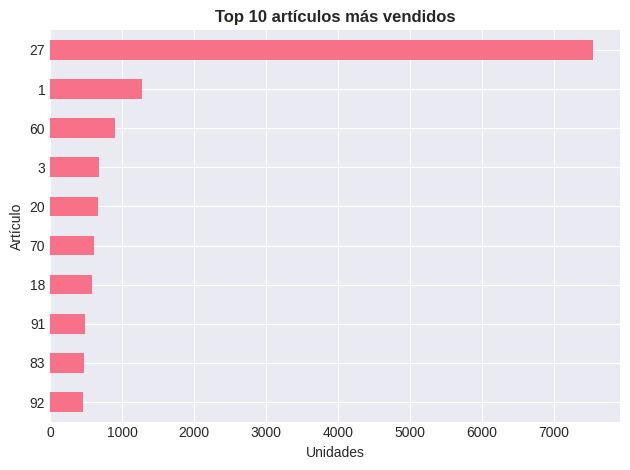

In [81]:
plt.figure()
ventas_por_articulo.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 artículos más vendidos', fontweight='bold')
plt.xlabel('Unidades')
plt.ylabel('Artículo')
plt.tight_layout()
plt.show()


===== MEJORES CLIENTES (POR IMPORTE) =====
Id_Cliente
100    5068615
29     3594260
11     2753250
1      1850845
9      1827565
22     1418410
50      909465
3       819670
28      662585
36      598085
Name: Importe, dtype: int64


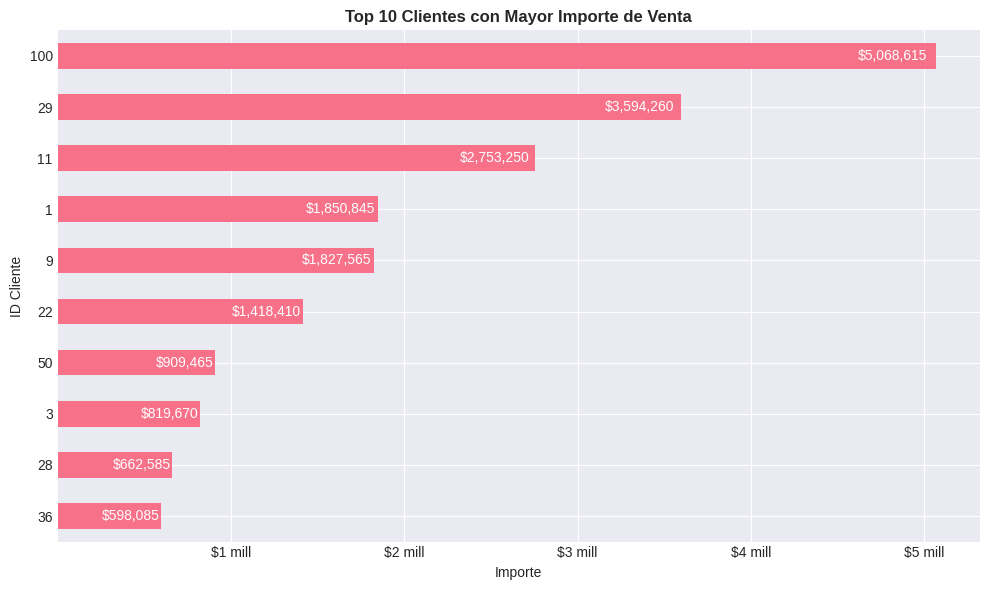


Los Top 10 Clientes representan el 77.84% del total de ventas.


In [82]:
import matplotlib.ticker as mtick

ventas_por_cliente = ventas.groupby('Id_Cliente')['Importe'].sum().sort_values(ascending=False)
print("\n===== MEJORES CLIENTES (POR IMPORTE) =====")
print(ventas_por_cliente.head(10))

plt.figure(figsize=(10, 6))
bars = ventas_por_cliente.head(10).sort_values(ascending=True).plot(kind='barh')
plt.title('Top 10 Clientes con Mayor Importe de Venta', fontweight='bold')
plt.xlabel('Importe')
plt.ylabel('ID Cliente')

# Custom x-axis ticks and labels for millions
x_ticks = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]
x_labels = ['$1 mill', '$2 mill', '$3 mill', '$4 mill', '$5 mill']
plt.xticks(x_ticks, x_labels)

# Display exact importe inside bars
for bar in bars.patches:
    plt.text(
        bar.get_width() - bar.get_width()*0.01, # x position (slightly inside the bar)
        bar.get_y() + bar.get_height() / 2,     # y position (center of the bar)
        f'${bar.get_width():,.0f}',             # text to display
        ha='right', va='center', color='white', fontsize=10 # alignment and color
    )

plt.tight_layout()
plt.show()

# Calculate the percentage of total sales represented by the top 10 clients
top_10_clientes_ventas = ventas_por_cliente.head(10).sum()
porcentaje_top_10 = (top_10_clientes_ventas / total_ventas) * 100

print(f"\nLos Top 10 Clientes representan el {porcentaje_top_10:,.2f}% del total de ventas.")

In [83]:
ventas_por_zona = ventas.groupby('Zona')['Importe'].sum().sort_values(ascending=False)
print("\n===== VENTAS POR ZONA =====")
print(ventas_por_zona)


===== VENTAS POR ZONA =====
Zona
1.0    7781585
6.0    4194945
4.0    4074880
2.0    3015945
5.0    2944745
3.0    1801495
7.0    1240715
Name: Importe, dtype: int64


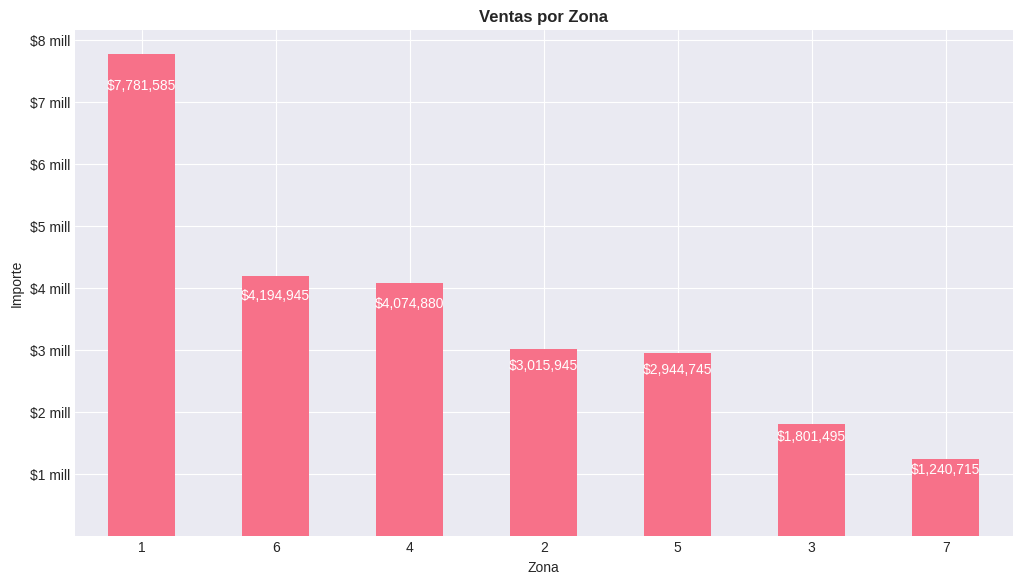


La zona con mayor ventas (Zona 1.0) representa el 31.06% del total de ventas.


In [84]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))
bars = ventas_por_zona.plot(kind='bar')
plt.title('Ventas por Zona', fontweight='bold')
plt.xlabel('Zona')
plt.ylabel('Importe')
plt.tight_layout()

# Get the current x-tick locations (0, 1, 2, ...) from the plot
tick_locations = bars.get_xticks()
# Get the original zone labels (e.g., 1.0, 6.0, ...) and convert to integers
new_x_labels = [str(int(zone)) for zone in ventas_por_zona.index]
plt.xticks(ticks=tick_locations, labels=new_x_labels, rotation=0)

# Custom y-axis ticks and labels for millions
y_ticks = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000, 6_000_000, 7_000_000, 8_000_000]
y_labels = ['$1 mill', '$2 mill', '$3 mill', '$4 mill', '$5 mill', '$6 mill', '$7 mill', '$8 mill']
plt.yticks(y_ticks, y_labels)

# Display exact importe inside bars
for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width() / 2, # x position (center of the bar)
        bar.get_height() - bar.get_height()*0.05, # y position (slightly inside the bar)
        f'${bar.get_height():,.0f}',             # text to display
        ha='center', va='top', color='white', fontsize=10 # alignment and color
    )

plt.show()

# Calculate the percentage of total sales for the top zone
max_ventas_zona = ventas_por_zona.max()
porcentaje_zona_mas_ventas = (max_ventas_zona / total_ventas) * 100
print(f"\nLa zona con mayor ventas (Zona {ventas_por_zona.idxmax()}) representa el {porcentaje_zona_mas_ventas:,.2f}% del total de ventas.")

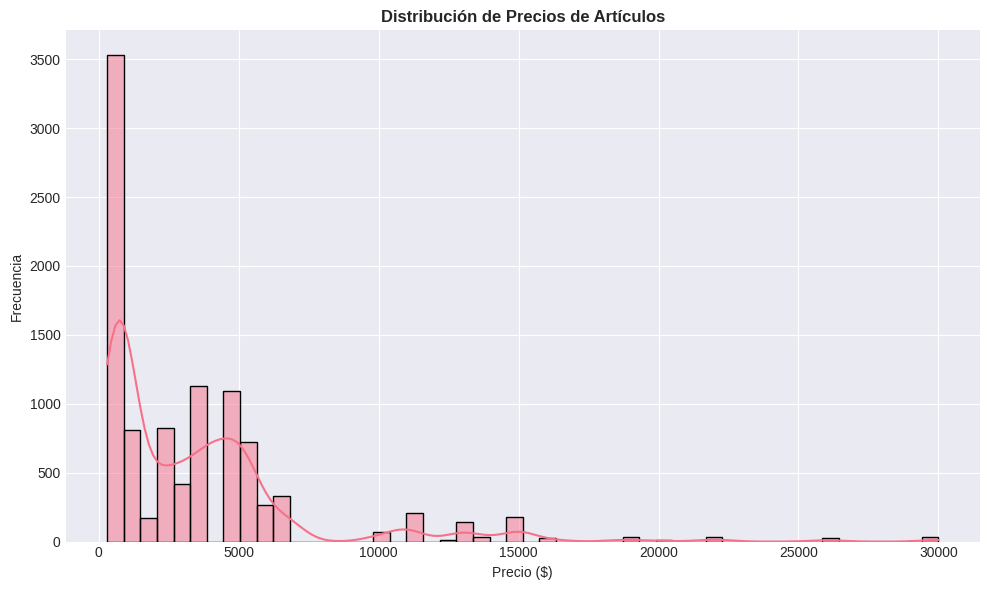

In [85]:
plt.figure(figsize=(10, 6))
sns.histplot(precios['Precio'], bins=50, kde=True)
plt.title('Distribución de Precios de Artículos', fontweight='bold')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.tight_layout()
plt.show()

## Identificar Artículos con Mayor Variación de Precio

### Subtask:
Determinar qué artículos han experimentado las mayores fluctuaciones en sus precios basándose en el rango o la desviación estándar.

In [86]:
variacion_precios_articulo = precios.groupby('Id_Artículo')['Precio'].agg(
    min_precio='min',
    max_precio='max',
    media_precio='mean',
    std_precio='std'
).reset_index()

variacion_precios_articulo['rango_precio'] = variacion_precios_articulo['max_precio'] - variacion_precios_articulo['min_precio']
variacion_precios_articulo['variacion_porcentual'] = (
    (variacion_precios_articulo['rango_precio'] / variacion_precios_articulo['min_precio']) * 100
)

# Handle cases where min_precio is 0 to avoid division by zero
variacion_precios_articulo.loc[variacion_precios_articulo['min_precio'] == 0, 'variacion_porcentual'] = 0

variacion_precios_articulo = variacion_precios_articulo.sort_values('variacion_porcentual', ascending=False)

print("\nArtículos con Mayor Variación de Precio (Top 10):")
print(variacion_precios_articulo.head(10))


Artículos con Mayor Variación de Precio (Top 10):
   Id_Artículo  min_precio  max_precio  media_precio   std_precio  \
0            0       10000       15000  12544.554455  1862.926475   
1            1         500         750    627.227723    93.146324   
2            2         500         750    627.227723    93.146324   
3            3         500         750    627.227723    93.146324   
4            4         700        1050    878.118812   130.404853   
5            5         500         750    627.227723    93.146324   
6            6         550         825    689.950495   102.460956   
7            7         550         825    689.950495   102.460956   
8            8         550         825    689.950495   102.460956   
9            9        2000        3000   2508.910891   372.585295   

   rango_precio  variacion_porcentual  
0          5000                  50.0  
1           250                  50.0  
2           250                  50.0  
3           250              

## Visualizar Importe Promedio por Venta a lo Largo de los Años

### Subtask:
Generar un gráfico de línea para visualizar la tendencia del importe promedio por venta a través de los años.

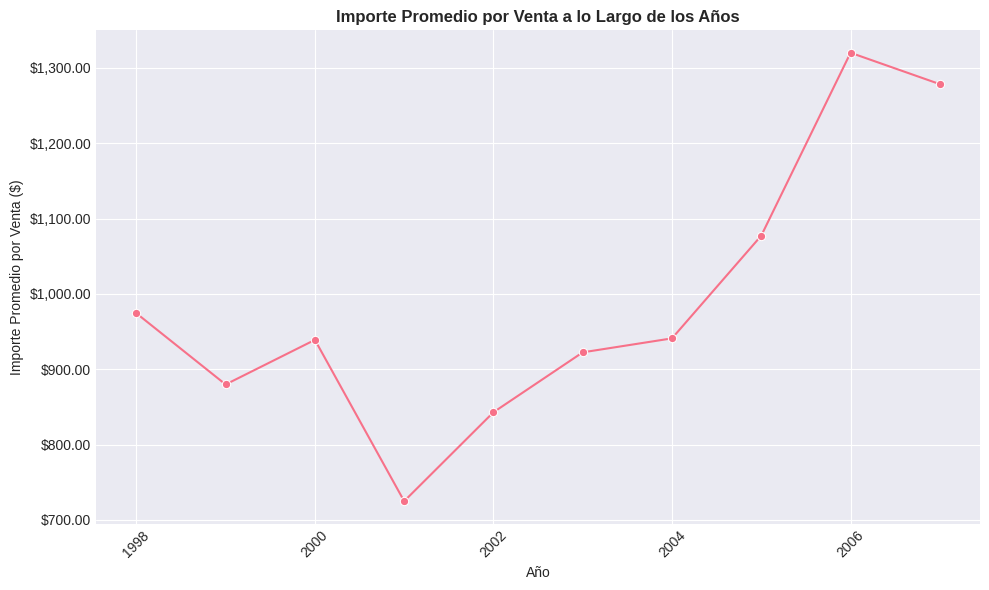

In [87]:
importe_promedio_anual = ventas.groupby('Año')['Importe'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=importe_promedio_anual.index, y=importe_promedio_anual.values, marker='o')
plt.title('Importe Promedio por Venta a lo Largo de los Años', fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Importe Promedio por Venta ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.2f}')) # Format y-axis as currency
plt.tight_layout()
plt.show()

In [88]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

**ÁRBOL DE DECISIÓN PREDICCIÓN PRECIO ARTÍCULO**

In [89]:
# Selección de variables
columnas_modelo = [ 'Id_Artículo', 'Año', 'Mes']
X = precios[columnas_modelo].copy()
y = precios['Precio'].copy()

# Quitar filas con NaN por seguridad
datos_modelo = pd.concat([X, y], axis=1).dropna()
X = datos_modelo[columnas_modelo].copy()
y = datos_modelo['Precio'].copy()

# Asegurar tipos numéricos
X = X.astype({
    'Id_Artículo': 'int32',
    'Año': 'int32',
    'Mes': 'int32',
})

# Dividimos el dataset en Train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Creacion del Árbol de decisión
arbol = DecisionTreeRegressor(
    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

# Entrenamos el arbol
arbol.fit(X_train, y_train)

# Evaluación del modelo haciendo predicciones
y_pred = arbol.predict(X_test)

# Calculamos las metricas para evaluar el rendimiento del modelo
# MSE

mse = mean_squared_error(y_test, y_pred)
# RMSE (raíz del MSE)
rmse = mse ** 0.5
# MAE
mae = mean_absolute_error(y_test, y_pred)
# R²
r2 = r2_score(y_test, y_pred)
print("---" * 90)
print("===== ÁRBOL DE DECISIÓN - RESULTADOS =====")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"R²: {r2:,.4f}")
print("---" * 90)
print("\n\n")

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
===== ÁRBOL DE DECISIÓN - RESULTADOS =====
MSE: 4,171,045.96
RMSE: 2,042.31
MAE: 1,394.97
R²: 0.7639
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------





### Importancia de las Características para la Predicción de Precio

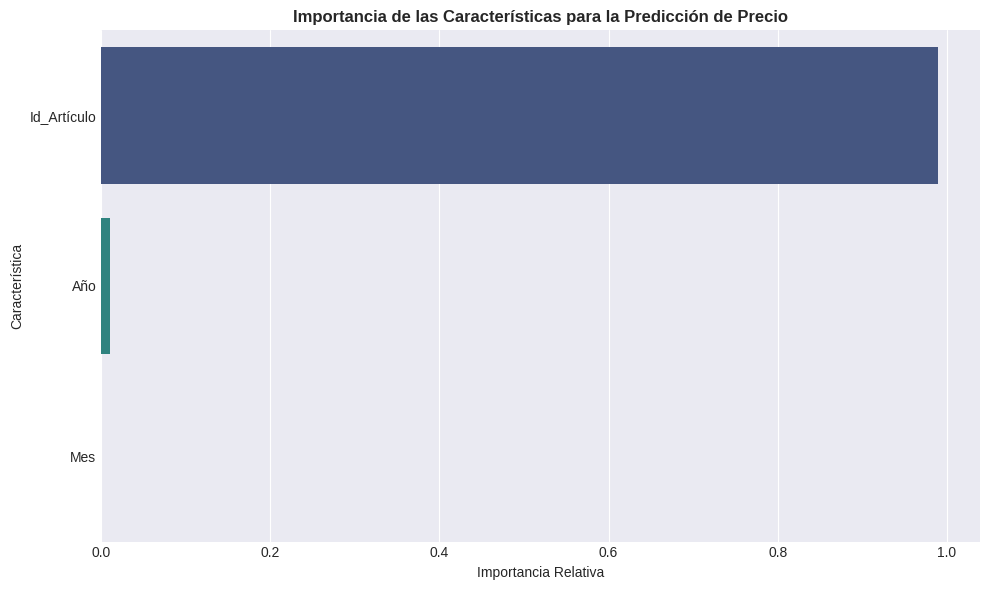

In [90]:
feature_importances = pd.Series(arbol.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Importancia de las Características para la Predicción de Precio', fontweight='bold')
plt.xlabel('Importancia Relativa')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

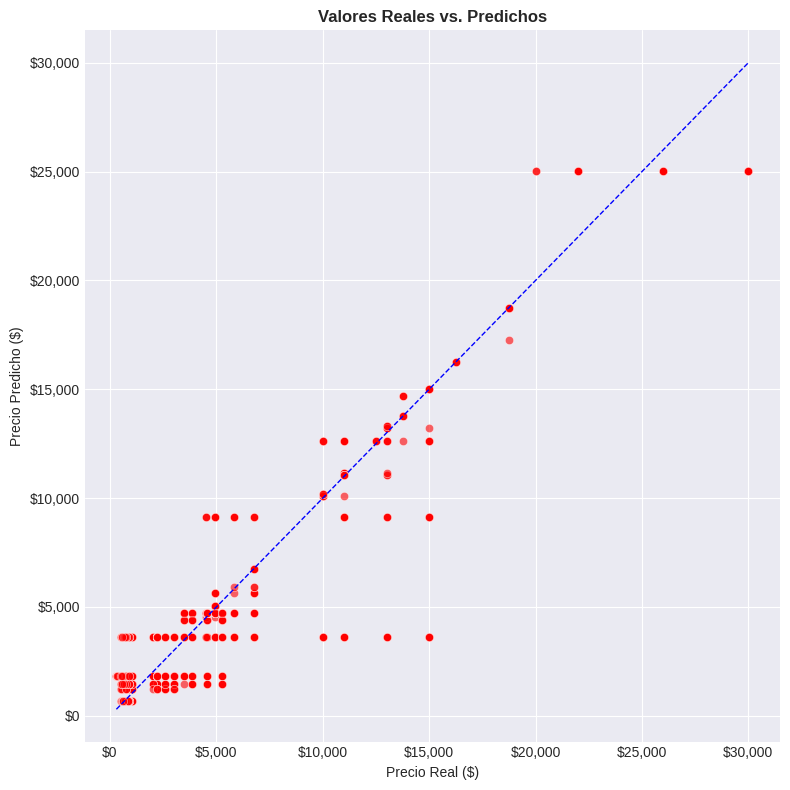

In [91]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='red')
plt.title('Valores Reales vs. Predichos', fontweight='bold')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')

# Add a 45-degree line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='blue', linestyle='--', linewidth=1)

plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

# **RANDOM FOREST PREDICCIÓN PRECIO ARTÍCULO**

In [92]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Selección de variables para el modelo de Random Forest Regressor
columnas_modelo = ['Id_Artículo', 'Año', 'Mes']
X = precios[columnas_modelo].copy()
y = precios['Precio'].copy()

# Quitar filas con nulas
datos_modelo = pd.concat([X, y], axis=1).dropna()
X = datos_modelo[columnas_modelo].copy()
y = datos_modelo['Precio'].copy()

# Asegurar tipos numéricos de forma segura
X = X.astype({
    'Id_Artículo': 'int32',
    'Año': 'int32',
    'Mes': 'int32',
})

# Parte el dataset en test y train
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Se crea el modelo RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento del modelo usando los datos de train
rf.fit(X_train, y_train)

# Evaluación del modelo
y_pred = rf.predict(X_test)

# A continuacion se calculas las metricas para evaluar el rendimiento del modelo
# MSE
mse_rf = mean_squared_error(y_test, y_pred)
# RMSE
rmse_rf = mse_rf ** 0.5
# MAE
mae_rf = mean_absolute_error(y_test, y_pred)
# R²
r2_rf = r2_score(y_test, y_pred)
print("-----" * 20)
print("===== RANDOM FOREST - RESULTADOS =====")
print(f"MSE: {mse_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"MAE: {mae_rf:,.2f}")
print(f"R²: {r2_rf:,.4f}")
print("-----" * 20)

----------------------------------------------------------------------------------------------------
===== RANDOM FOREST - RESULTADOS =====
MSE: 22,673.99
RMSE: 150.58
MAE: 43.06
R²: 0.9987
----------------------------------------------------------------------------------------------------


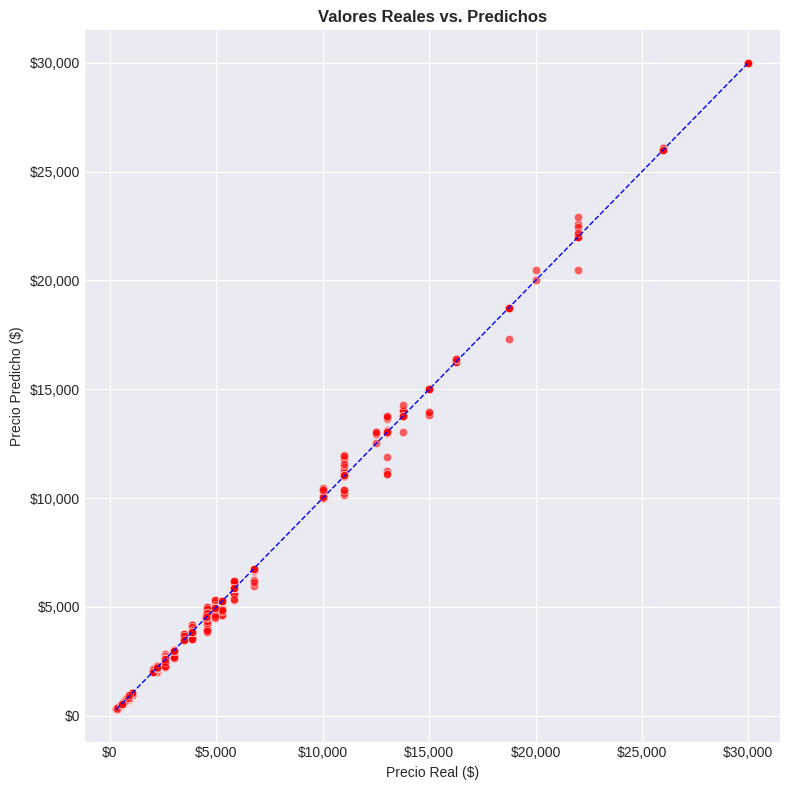

In [93]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='red')
plt.title('Valores Reales vs. Predichos', fontweight='bold')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')

# Add a 45-degree line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='blue', linestyle='--', linewidth=1)

plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

In [94]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

columnas_modelo = ['Id_Artículo', 'Año', 'Mes']
X = precios[columnas_modelo].copy()
y = precios['Precio'].copy()

datos_modelo = pd.concat([X, y], axis=1).dropna()
X = datos_modelo[columnas_modelo].astype('float32')
y = datos_modelo['Precio'].astype('float32')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-----" * 20)
print("===== XGBOOST REGRESSOR - RESULTADOS =====")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"R²: {r2:,.4f}")

----------------------------------------------------------------------------------------------------
===== XGBOOST REGRESSOR - RESULTADOS =====
MSE: 114,752.38
RMSE: 338.75
MAE: 223.52
R²: 0.9935


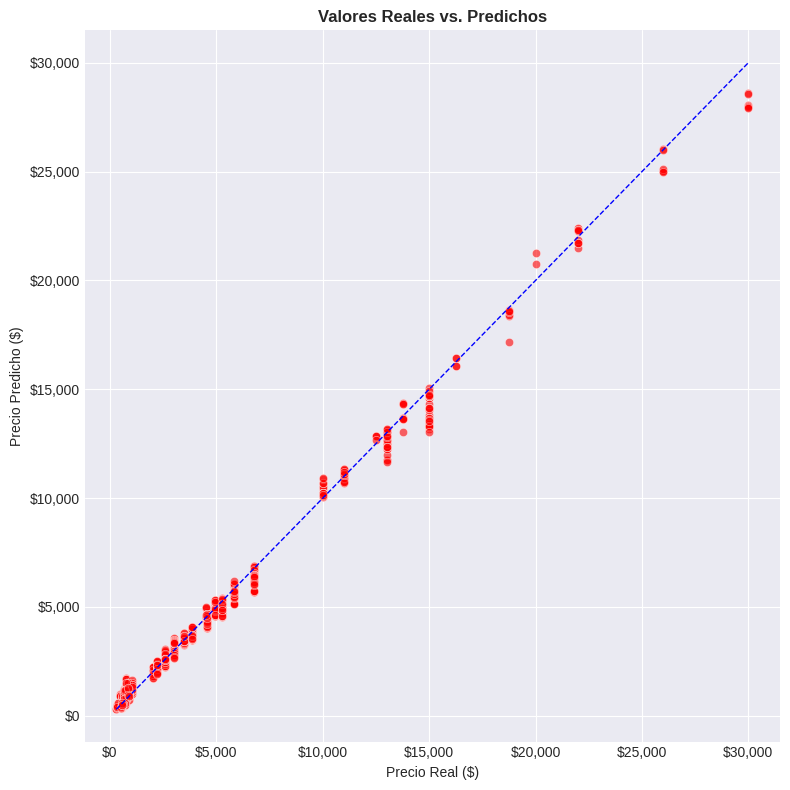

In [95]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='red')
plt.title('Valores Reales vs. Predichos', fontweight='bold')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')

# Add a 45-degree line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='blue', linestyle='--', linewidth=1)

plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

# **RED NEURONAL**

## Preparar Datos para Red Neuronal

### Subtask:
Seleccionar 'Id_Artículo', 'Año' y 'Mes' del DataFrame 'precios' como características (X) para predecir 'Precio' (y). Escalar tanto las características como el objetivo utilizando StandardScaler para optimizar el rendimiento de la red neuronal. Finalmente, dividir los datos escalados en conjuntos de entrenamiento y prueba.


**Reasoning**:
The subtask requires preparing the data for a neural network by selecting features and target, scaling them using `StandardScaler`, and then splitting them into training and testing sets. This step imports the necessary class, performs the selection and scaling, and finally the split.



In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Características "X" de df precios para predecir el "precio" de los artículos
X = precios[['Id_Artículo', 'Año', 'Mes']].copy()

# Selección de variable a predecir
y = precios['Precio'].copy()

# Asegurar tipos numéricos y manejar posibles NaN antes de escalar
X = X.astype({'Id_Artículo': 'float32', 'Año': 'float32', 'Mes': 'float32'})
y = y.astype('float32')

#Escalar variables
scaler_X = StandardScaler()
scaler_y = StandardScaler()

#Fit scaler_X to X and transform X, storing the result in X_scaled.
X_scaled = scaler_X.fit_transform(X)

#Fit scaler_y to y (reshaped to y.values.reshape(-1, 1)) and transform y, storing the result in y_scaled.
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

#Entrenamiento y prueba
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled, y_scaled,
    test_size=0.2,
    random_state=42
)

print("Datos preparados y escalados para la Red Neuronal.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test_scaled shape: {y_test_scaled.shape}")

Datos preparados y escalados para la Red Neuronal.
X_train_scaled shape: (8080, 3)
y_train_scaled shape: (8080, 1)
X_test_scaled shape: (2020, 3)
y_test_scaled shape: (2020, 1)


**Reasoning**:
The subtask requires building and training a sequential Keras/TensorFlow neural network, then evaluating its performance and visualizing predictions. This step involves importing TensorFlow, defining the model architecture, compiling it, training it, making predictions on the test set, calculating evaluation metrics (MSE, RMSE, MAE, R-squared), and finally generating a scatter plot to visualize actual vs. predicted prices.



In [106]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.ticker as mtick

# Modelo de red neuronal secuencial con Keras de TensorFlow
#    - Capa de entrada: appropriate for the number of features in X_train_scaled.
#    - 2 capas ocultas densas: first with 64 neurons, second with 32 neurons, both using 'relu' activation.
#    - Capa de salida densa: 1 neuron with 'linear' activation for regression.
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

# Propiedades para el modelo con optimizador "Adam y 'mean_squared_error' como función de perdida "
model.compile(optimizer='Adam', loss='mean_squared_error')

#Entrenamiento

history = model.fit(
    X_train_scaled, y_train_scaled, #datos de entrada, resultados esperados
    epochs=1000, #vueltas/revisión de los datos
    batch_size=32,
    validation_split=0.2,
    verbose=0 #No imprimir mucha data al entrenar
)

print("Red Neuronal Entrenada.")

# 4. Make predictions on the scaled test data (X_test_scaled).
y_pred_scaled = model.predict(X_test_scaled)

# 5. Inverse transform the scaled predictions and actual values to their original scale using scaler_y.
y_pred_nn = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_scaled)


mse_nn = mean_squared_error(y_test_original, y_pred_nn)
rmse_nn = mse_nn ** 0.5
mae_nn = mean_absolute_error(y_test_original, y_pred_nn)
r2_nn = r2_score(y_test_original, y_pred_nn)

print("\n===== RED NEURONAL - RESULTADOS =====")
print(f"MSE: {mse_nn:,.2f}")
print(f"RMSE: {rmse_nn:,.2f}")
print(f"MAE: {mae_nn:,.2f}")
print(f"R²: {r2_nn:,.4f}")


Red Neuronal Entrenada.
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

===== RED NEURONAL - RESULTADOS =====
MSE: 2,628,142.75
RMSE: 1,621.15
MAE: 1,202.52
R²: 0.8512


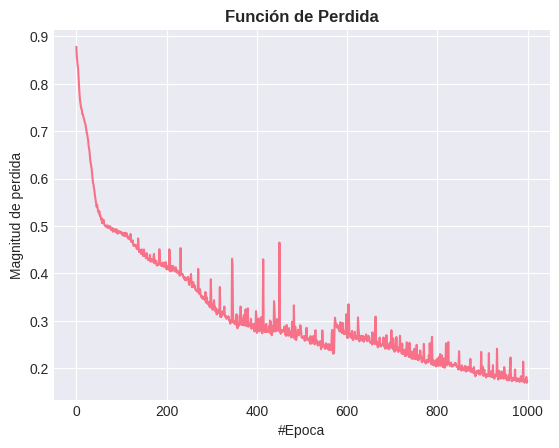

In [107]:
plt.title('Función de Perdida', fontweight='bold')
plt.xlabel("#Epoca")
plt.ylabel("Magnitud de perdida")
plt.plot(history.history["loss"])
plt.show()

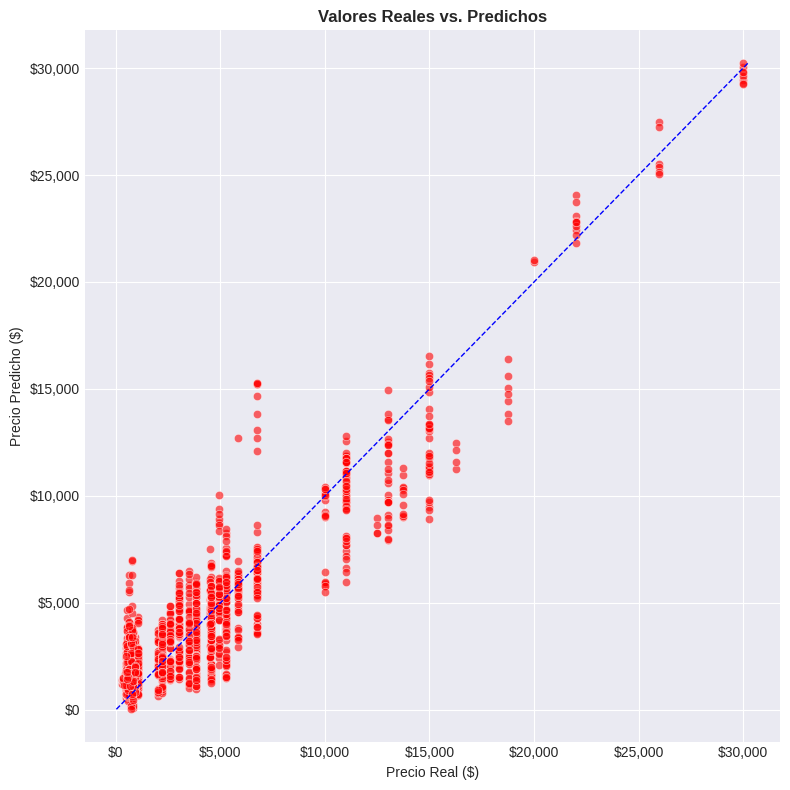

In [110]:
# Gráfico de valores reales(y_test_original) vs valores predichos (y_pred_nn).

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test_original.flatten(), y=y_pred_nn.flatten(), alpha=0.6, color='red')
plt.title('Valores Reales vs. Predichos', fontweight='bold')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')

min_val = min(y_test_original.min(), y_pred_nn.min())
max_val = max(y_test_original.max(), y_pred_nn.max())
plt.plot([min_val, max_val], [min_val, max_val], color='blue', linestyle='--', linewidth=1,)

plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

**Reasoning**:
The next step is to prepare the `ventas` DataFrame for K-NN classification as per the subtask. This involves calculating aggregated client features (`total_importe`, `num_unique_articles`), segmenting clients based on `total_importe`, scaling the relevant features, and splitting the data for training and testing.



In [111]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular importe total de cada cliente (suma de 'Importe') y num_unique_articles (artículos únicos)
client_features = ventas.groupby('Id_Cliente').agg(
    total_importe=('Importe', 'sum'),
    num_unique_articles=('Id_Artículo', 'nunique')
).reset_index()

# 2. Create a 'segmento_cliente' column.
#    Classify clients with total_importe above the 75th percentile as 'High_Value' and the rest as 'Regular_Value'.
percentile_75 = client_features['total_importe'].quantile(0.75)
client_features['segmento_cliente'] = client_features['total_importe'].apply(
    lambda x: 'High_Value' if x > percentile_75 else 'Regular_Value'
)

# Prepare features (X) and target (y) for K-NN
X_knn = client_features[['num_unique_articles', 'total_importe']]
y_knn = client_features['segmento_cliente']

# 3. Scale the numerical features `num_unique_articles` and `total_importe` using `StandardScaler`.
scaler_knn = StandardScaler()
X_knn_scaled = scaler_knn.fit_transform(X_knn)

# 4. Split this data into training and test sets.
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn_scaled, y_knn,
    test_size=0.2,
    random_state=42,
    stratify=y_knn # Stratify to maintain class distribution
)

print("Datos preparados y escalados para K-NN Classification.")
print(f"X_train_knn shape: {X_train_knn.shape}")
print(f"y_train_knn shape: {y_train_knn.shape}")
print(f"X_test_knn shape: {X_test_knn.shape}")
print(f"y_test_knn shape: {y_test_knn.shape}")

Datos preparados y escalados para K-NN Classification.
X_train_knn shape: (32, 2)
y_train_knn shape: (32,)
X_test_knn shape: (8, 2)
y_test_knn shape: (8,)


**Reasoning**:
The subtask requires training a `KNeighborsClassifier` and then evaluating its performance using various metrics and visualizing the confusion matrix. This step will implement the model training, prediction, metric calculation, and plot generation.



KNeighborsClassifier model trained.

===== K-NN CLASSIFIER - RESULTADOS =====
Accuracy: 0.7500
Precision: 0.5000
Recall: 1.0000
F1-Score: 0.6667


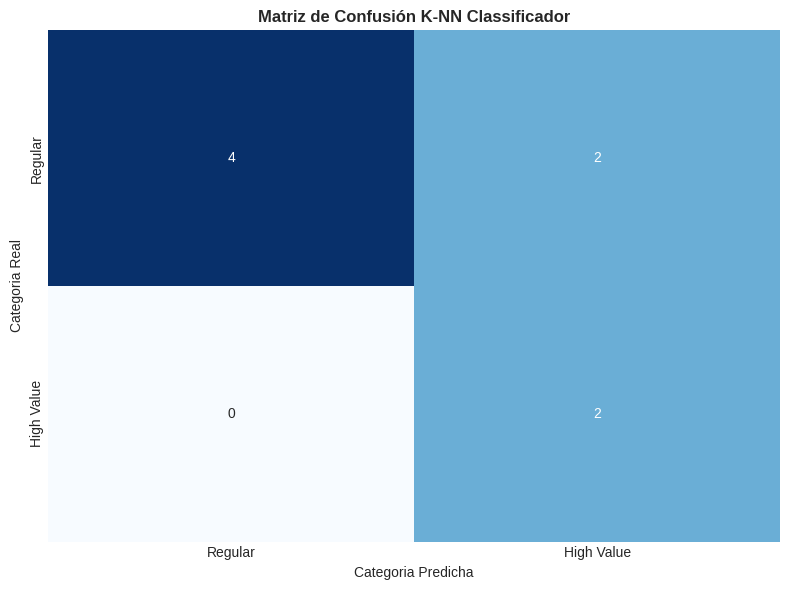

In [115]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Train a KNeighborsClassifier with n_neighbors=5.
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_knn, y_train_knn)

print("KNeighborsClassifier model trained.")

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_knn)

# 6. Evaluate the K-NN classifier's performance.
accuracy = accuracy_score(y_test_knn, y_pred_knn)
precision = precision_score(y_test_knn, y_pred_knn, pos_label='High_Value')
recall = recall_score(y_test_knn, y_pred_knn, pos_label='High_Value')
f1 = f1_score(y_test_knn, y_pred_knn, pos_label='High_Value')

print("\n===== K-NN CLASSIFIER - RESULTADOS =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Visualize its performance with a confusion matrix.
cm = confusion_matrix(y_test_knn, y_pred_knn, labels=['Regular_Value', 'High_Value'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Regular', 'High Value'],
            yticklabels=['Regular', 'High Value'])
plt.title('Matriz de Confusión K-NN Classificador', fontweight='bold')
plt.xlabel('Categoria Predicha')
plt.ylabel('Categoria Real')
plt.tight_layout()
plt.show()

## Resumen y Aplicaciones Estratégicas

### Modelo de Predicción de Precios (Red Neuronal)

El modelo de Red Neuronal fue utilizado para predecir el precio de los artículos basándose en el `Id_Artículo`, `Año` y `Mes`. Los resultados obtenidos fueron:

*   **MSE:** 2,628,142.75
*   **RMSE:** 1,621.15
*   **MAE:** 1,202.52
*   **R²:** 0.8512

El coeficiente R² de 0.8512 indica que el modelo explica aproximadamente el 85% de la variabilidad en los precios, lo que sugiere que hay otros factores no incluidos en el modelo que influyen significativamente en el precio. Aunque el MAE de ~$1,202.52 indica una desviación promedio considerable, este modelo puede ser útil para:

*   **Optimización de Precios:** Identificar tendencias y patrones de precios históricos para ajustar estrategias de precios futuras, especialmente para nuevos productos o en mercados volátiles. La comprensión de cómo el `Id_Artículo`, `Año` y `Mes` impactan los precios puede guiar decisiones sobre cuándo y cuánto ajustar los precios.
*   **Gestión de Inventario:** Predecir la demanda futura basada en posibles fluctuaciones de precios, lo que ayuda a optimizar los niveles de stock y reducir el exceso o la escasez de inventario.
*   **Análisis de Sensibilidad:** Evaluar cómo cambios en el año o mes (que pueden reflejar estacionalidad o eventos macroeconómicos) afectan el precio de los artículos, permitiendo una planificación más robusta.

### Modelo de Segmentación de Clientes (K-NN Classifier)

El clasificador K-NN se utilizó para segmentar clientes en 'High_Value' y 'Regular_Value' basándose en su `total_importe` y `num_unique_articles`. Los resultados fueron:

*   **Accuracy:** 0.7500
*   **Precision (High_Value):** 0.5000
*   **Recall (High_Value):** 1.0000
*   **F1-Score (High_Value):** 0.6667

Un recall del 100% para clientes 'High_Value' es notable, ya que significa que el modelo identificó correctamente a todos los clientes de alto valor en el conjunto de prueba. Sin embargo, una precisión del 50% indica que muchos clientes predichos como 'High_Value' son en realidad 'Regular_Value' (falsos positivos). A pesar de esto, este modelo ofrece valor para:

*   **Campañas de Marketing Dirigido:** La alta tasa de recall para 'High_Value' significa que podemos estar seguros de no perder a ningún cliente importante para campañas exclusivas o programas de lealtad. La precisión más baja sugiere que las campañas dirigidas a 'High_Value' podrían incluir a algunos 'Regular_Value', lo que podría diluir un poco el mensaje pero aún así garantiza que no se pase por alto a ningún cliente clave.
*   **Gestión de Relaciones con el Cliente (CRM):** Priorizar el servicio al cliente y los esfuerzos de retención para los segmentos de alto valor. Comprender qué clientes son los más valiosos permite una asignación eficiente de recursos.
*   **Personalización de Ofertas:** Desarrollar ofertas y promociones personalizadas para cada segmento, aumentando la probabilidad de ventas repetidas y la satisfacción del cliente. Por ejemplo, a los clientes 'High_Value' se les podría ofrecer un adelanto de nuevas colecciones o descuentos exclusivos.

### Conclusión General

Ambos modelos, aunque con diferentes niveles de rendimiento y propósitos, proporcionan insights accionables para la industria de la joyería. El modelo de precios puede ayudar a la dirección financiera y de producto a optimizar los ingresos, mientras que el modelo de segmentación de clientes es fundamental para los equipos de marketing y ventas para construir relaciones más sólidas y eficientes con la clientela.